In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "../../lab5.csv"

df = pd.read_csv(file_path)
df_original = df.copy()

print(df.shape)

(284807, 31)


In [5]:
display(df.head())
df.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
print(df["Class"].value_counts())
print((df["Class"].value_counts(normalize=True) * 100).round(4))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


In [14]:
# Missing values
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

# Duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Total duplicate rows:", duplicate_count, f"({round(duplicate_percentage, 4)} %)")

Total missing values: 0
Total duplicate rows: 0 (0.0 %)


In [11]:
# REMOVE DUPLICATED

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Rows removed:", before - after)
print("New dataset shape:", df.shape)

Rows before removing duplicates: 284807
Rows after removing duplicates: 283726
Rows removed: 1081
New dataset shape: (283726, 31)


In [12]:
print(df["Class"].value_counts())
print((df["Class"].value_counts(normalize=True) * 100).round(4))

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


In [17]:
# OUTLIER ANALYSIS

print("Transaction Amount Statistics:")
display(df["Amount"].describe())

# Quartiles and IQR
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)]

print("\nNumber of outliers:", len(outliers), f"({round(len(outliers) / len(df) * 100, 4)} %)")

Transaction Amount Statistics:


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
Lower bound: -102.26500000000001
Upper bound: 185.375

Number of outliers: 31685 (11.1675 %)


In [ ]:
display(df.groupby("Class")["Amount"].describe())

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


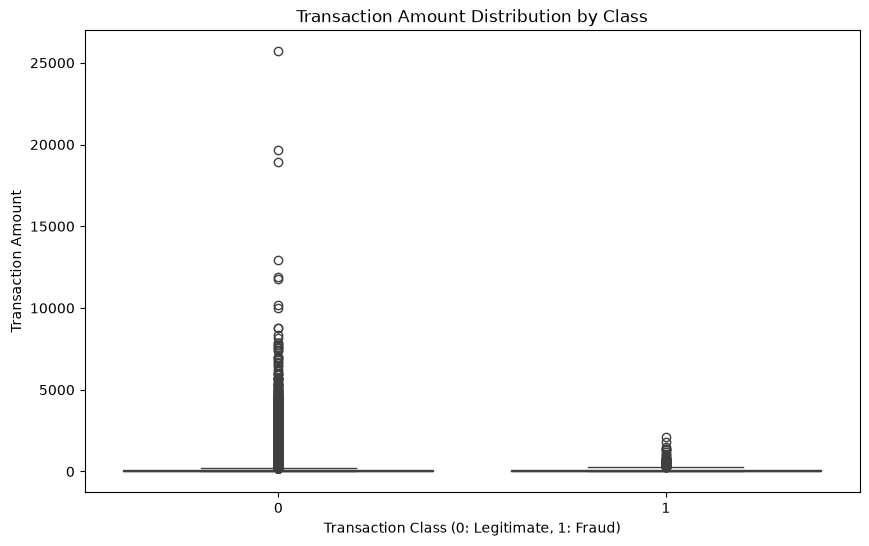

In [19]:
# TRANSACTION AMOUNT BY CLASS

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Class (0: Legitimate, 1: Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

# Featuring

In [20]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

print("Minimum hour:", df["Hour"].min())
print("Maximum hour:", df["Hour"].max())

Minimum hour: 0
Maximum hour: 23


In [21]:
fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
    .sort_index()
)

display(fraud_by_hour)

Hour
0      6
1     10
2     48
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    28
18    28
19    19
20    18
21    16
22     9
23    17
dtype: int64

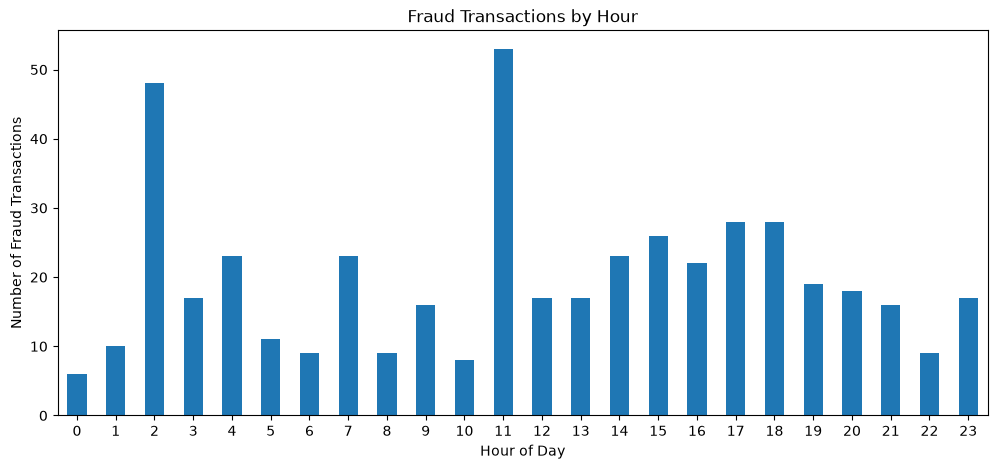

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=0)

plt.show()

In [23]:
df["Log_Amount"] = np.log1p(df["Amount"])
display(df[["Amount", "Log_Amount"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Amount,283726.0,88.472687,250.399437,0.0,5.60000,22.000000,77.510000,25691.160000
Log_Amount,283726.0,3.153760,1.657080,0.0,1.88707,3.135494,4.363226,10.153941


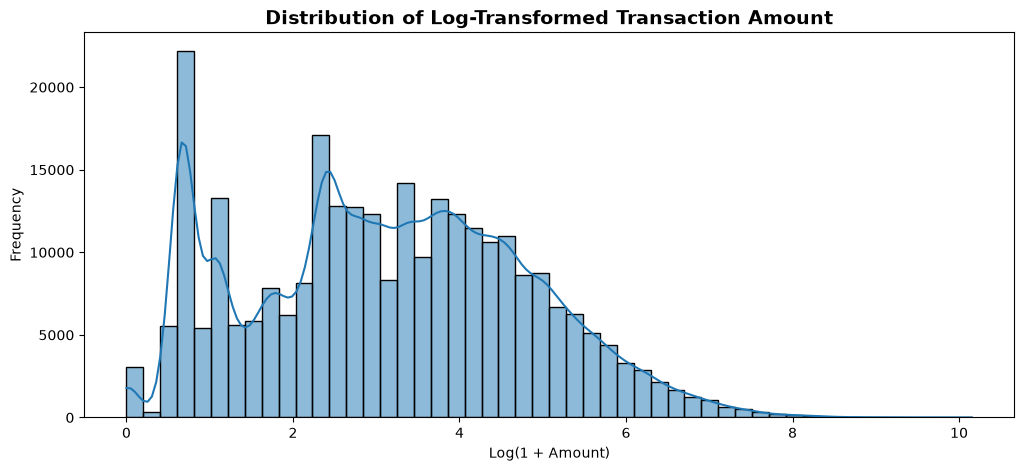

In [25]:
plt.figure(figsize=(12, 5))

sns.histplot(data=df, x="Log_Amount", bins=50, kde=True)

plt.title("Distribution of Log-Transformed Transaction Amount", fontsize=14, fontweight="bold")
plt.xlabel("Log(1 + Amount)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# FRAUD BY HOUR

hour_analysis = (
    df.groupby("Hour")["Class"].agg(Total_Transactions="count",Fraud_Count="sum"))

hour_analysis["Fraud_Rate_%"] = (hour_analysis["Fraud_Count"] /hour_analysis["Total_Transactions"] * 100)

# display(hour_analysis)

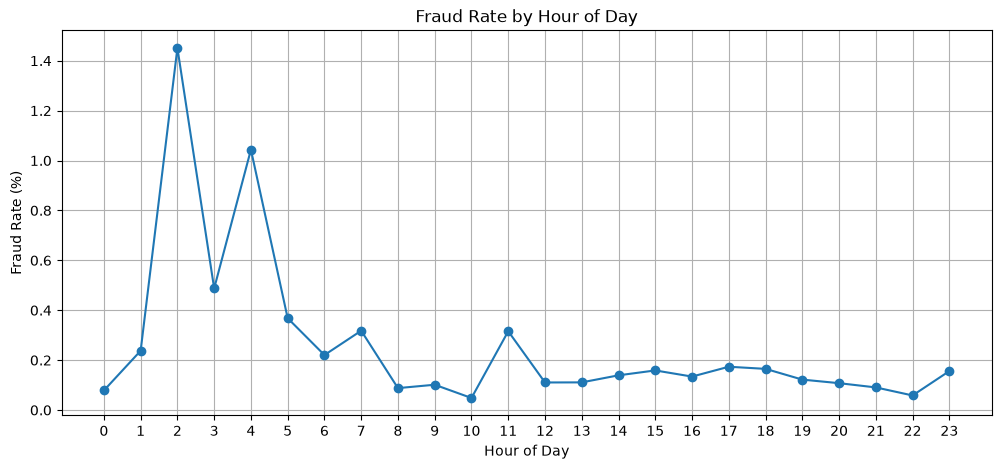

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_analysis.index,
    hour_analysis["Fraud_Rate_%"],
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [29]:
summary = {
    "Original Rows": len(df_original),
    "Final Rows": len(df),
    "Rows Removed": len(df_original) - len(df),
    "Original Columns": df_original.shape[1],
    "Final Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows Removed": df_original.duplicated().sum(),
    "Legitimate Transactions": (df["Class"] == 0).sum(),
    "Fraudulent Transactions": (df["Class"] == 1).sum()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Original Rows,284807
1,Final Rows,283726
2,Rows Removed,1081
3,Original Columns,31
4,Final Columns,33
5,Missing Values,0
6,Duplicate Rows Removed,1081
7,Legitimate Transactions,283253
8,Fraudulent Transactions,473


In [ ]:
output_path = "../../lab5_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved to:")
print(output_path)

# Modeling

In [30]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [32]:
# TRAIN / VAL / TEST SPLIT

from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (170235, 32)
Val: (56745, 32)
Test: (56746, 32)


In [33]:
# FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [35]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

def evaluate(header: str, y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(header)
    print("----------------------------")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("PR-AUC   :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [37]:
evaluate("Logistic Regression", y_test, y_pred_logistic, y_prob_logistic)

Logistic Regression
----------------------------
Accuracy : 0.9726
Precision: 0.051
Recall   : 0.8737
F1 Score : 0.0965
ROC-AUC  : 0.9678
PR-AUC   : 0.686

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



# Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [39]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [40]:
evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf)

Random Forest
----------------------------
Accuracy : 0.9994
Precision: 0.8571
Recall   : 0.7579
F1 Score : 0.8045
ROC-AUC  : 0.9601
PR-AUC   : 0.7941

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.76      0.80        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



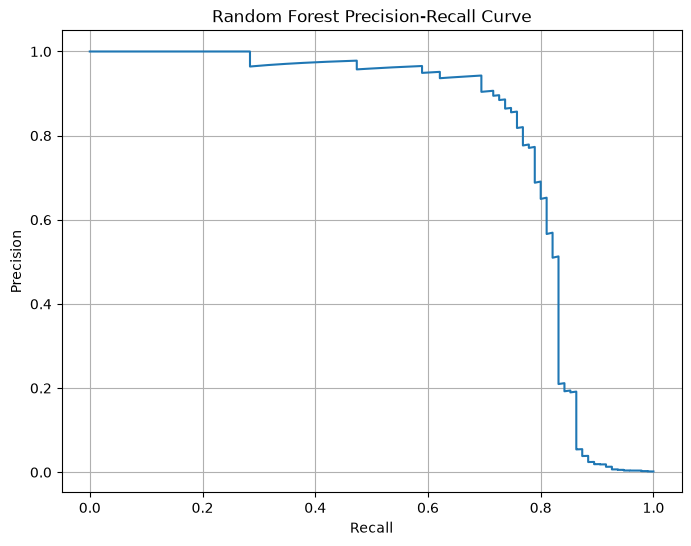

In [41]:
# PRECISION-RECALL CURVE

from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.grid(True)

plt.show()

In [ ]:
# THRESHOLD ANALYSIS

from sklearn.metrics import precision_score, recall_score, f1_score

y_prob_rf_val = rf_model.predict_proba(X_val)[:, 1]

thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
threshold_results = []

for threshold in thresholds_to_test:
    y_threshold = (
        y_prob_rf_val >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_val,
            y_threshold,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

display(threshold_results.round(4))

,Threshold,Precision,Recall,F1 Score
0,0.1,0.1750,0.8936,0.2927
1,0.2,0.4221,0.8936,0.5734
2,0.3,0.6136,0.8617,0.7168
3,0.4,0.7297,0.8617,0.7902
4,0.5,0.7843,0.8511,0.8163
5,0.6,0.8421,0.8511,0.8466
6,0.7,0.9167,0.8191,0.8652
7,0.8,0.9351,0.7660,0.8421
8,0.9,0.9508,0.6170,0.7484


In [44]:
# SELECT BEST VALIDATION THRESHOLD

best_threshold_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best validation threshold:", best_threshold)
print(
    "Validation F1 Score:",
    round(best_threshold_row["F1 Score"], 4)
)

Best validation threshold: 0.7
Validation F1 Score: 0.8652


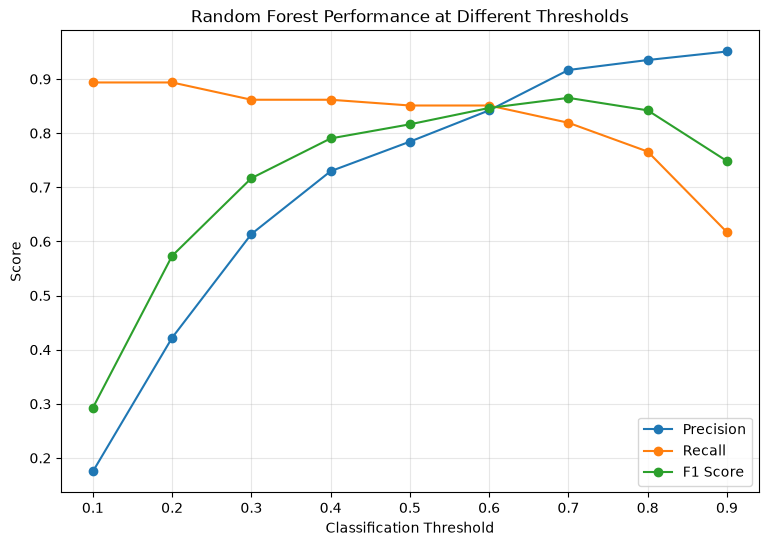

In [45]:
# THRESHOLD PERFORMANCE GRAPH

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title("Random Forest Performance at Different Thresholds")

plt.legend()
plt.grid(alpha=0.3)

plt.show()